<div style="background:#262766;color:white;padding:10px;text-align:center;font-size:26px">
Exploration des données
</div>

In [81]:
# ==========================
# Import des bibliothèques
# ==========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [82]:
# ==========================
# Import des données
# ==========================
df = pd.read_csv("export/donnees_meteo_finales_2021_2026.csv")

In [83]:
# ==========================
# Taille du jeu de données
# ==========================
print(f"Nombre de lignes : {df.shape[0]:,}".replace(",", " "))
print(f"Nombre de colonnes : {df.shape[1]}")

Nombre de lignes : 133 878
Nombre de colonnes : 87


In [84]:
print(df.columns.tolist())

['NUM_POSTE', 'NOM_USUEL', 'LAT', 'LON', 'ALTI', 'AAAAMM', 'RR', 'QRR', 'NBRR', 'RRAB', 'QRRAB', 'RRABDAT', 'NBJRR1', 'NBJRR5', 'NBJRR10', 'NBJRR30', 'NBJRR50', 'NBJRR100', 'NBPMERM', 'TX', 'QTX', 'NBTX', 'TXAB', 'QTXAB', 'TXDAT', 'TXMIN', 'QTXMIN', 'TXMINDAT', 'NBJTX0', 'NBJTX25', 'NBJTX30', 'NBJTX35', 'NBJTXI20', 'NBJTXI27', 'NBJTXS32', 'TN', 'QTN', 'NBTN', 'TNAB', 'QTNAB', 'TNDAT', 'TNMAX', 'QTNMAX', 'TNMAXDAT', 'NBJTN5', 'NBJTN10', 'NBJTNI10', 'NBJTNI15', 'NBJTNI20', 'NBJTNS20', 'NBJTNS25', 'NBJGELEE', 'TAMPLIM', 'QTAMPLIM', 'TAMPLIAB', 'QTAMPLIAB', 'TAMPLIABDAT', 'NBTAMPLI', 'TM', 'QTM', 'NBTM', 'TMM', 'QTMM', 'NBTMM', 'NBJTMS24', 'TMMIN', 'QTMMIN', 'TMMINDAT', 'TMMAX', 'QTMMAX', 'TMMAXDAT', 'NBUN', 'NBUX', 'NBUM', 'ETP', 'QETP', 'NBFXI', 'NBFXI3S', 'NBFXY', 'NBFFM', 'NBINST', 'NBGLOT', 'NBDIFT', 'NBDIRT', 'NBHNEIGEF', 'DEPARTEMENT', 'MOIS_ANNEE']


In [85]:
# ==========================
# Analyse exploratoire colonne par colonne
# ==========================
#Cette fonction permet de parcourir les colonnes et de les analyser selon différents critères
def analyze_columns_line_by_line(df):    
    print("\n📊 **Analyse Exploratoire du DataFrame** 📊\n")
    for col in df.columns:
        print(f"🔹 **Colonne :** {col}")
        print(f"   - Type de données : {df[col].dtype}")
        print(f"   - Valeurs manquantes : {df[col].isnull().sum()}")
        print(f"   - Nbre de valeurs différentes : {df[col].nunique(dropna=True)}")
        print(f"   - Nombre de valeurs présentes une seule fois : {(df[col].value_counts() == 1).sum()}")
        print(f"   - Min : {df[col].dropna().min()}")
        print(f"   - Max : {df[col].dropna().max()}")
        print("-" * 50)  # Séparateur visuel entre les colonnes

# Analyse exploratoire colonne par colonne
analyze_columns_line_by_line(df)


📊 **Analyse Exploratoire du DataFrame** 📊

🔹 **Colonne :** NUM_POSTE
   - Type de données : int64
   - Valeurs manquantes : 0
   - Nbre de valeurs différentes : 2502
   - Nombre de valeurs présentes une seule fois : 25
   - Min : 1014002
   - Max : 95690001
--------------------------------------------------
🔹 **Colonne :** NOM_USUEL
   - Type de données : object
   - Valeurs manquantes : 0
   - Nbre de valeurs différentes : 2495
   - Nombre de valeurs présentes une seule fois : 25
   - Min : ABBEVILLE
   - Max : ZONZA
--------------------------------------------------
🔹 **Colonne :** LAT
   - Type de données : float64
   - Valeurs manquantes : 0
   - Nbre de valeurs différentes : 2406
   - Nombre de valeurs présentes une seule fois : 24
   - Min : 41.374833
   - Max : 51.055833
--------------------------------------------------
🔹 **Colonne :** LON
   - Type de données : float64
   - Valeurs manquantes : 0
   - Nbre de valeurs différentes : 2433
   - Nombre de valeurs présentes une seu

### Vérification des codes qualité

In [86]:
# ==========================
# Analyse Répartition des codes qualité
# ==========================

# Colonnes de qualité
q_cols = [col for col in df.columns if col.startswith("Q")]

print(f"Nombre de colonnes qualité : {len(q_cols)}")
print(q_cols)

# Répartition des codes qualité
for col in q_cols:
    print("\n" + "=" * 50)
    print(f"{col}")
    print(df[col].value_counts(dropna=False).sort_index())

Nombre de colonnes qualité : 15
['QRR', 'QRRAB', 'QTX', 'QTXAB', 'QTXMIN', 'QTN', 'QTNAB', 'QTNMAX', 'QTAMPLIM', 'QTAMPLIAB', 'QTM', 'QTMM', 'QTMMIN', 'QTMMAX', 'QETP']

QRR
QRR
0.0        12
1.0    129438
2.0         8
9.0       336
NaN      4084
Name: count, dtype: int64

QRRAB
QRRAB
0.0        66
1.0    129591
9.0       142
NaN      4079
Name: count, dtype: int64

QTX
QTX
1.0    122956
2.0        12
9.0       716
NaN     10194
Name: count, dtype: int64

QTXAB
QTXAB
0.0        24
1.0    123107
2.0         1
9.0       557
NaN     10189
Name: count, dtype: int64

QTXMIN
QTXMIN
0.0         2
1.0    123135
2.0         1
9.0       551
NaN     10189
Name: count, dtype: int64

QTN
QTN
1.0    122966
2.0        16
9.0       714
NaN     10182
Name: count, dtype: int64

QTNAB
QTNAB
0.0         7
1.0    123133
2.0         2
9.0       558
NaN     10178
Name: count, dtype: int64

QTNMAX
QTNMAX
0.0        15
1.0    123130
2.0         3
9.0       553
NaN     10177
Name: count, dtype: int64

QTAMPLIM

In [87]:
# Lignes contenant au moins un code qualité = 2
masque = (df[q_cols] == 2).any(axis=1)

print("Nombre de lignes concernées :", masque.sum())
print("Nombre de bornes concernées :", df.loc[masque, "NUM_POSTE"].nunique())

Nombre de lignes concernées : 31
Nombre de bornes concernées : 26


In [88]:
# Suppression des lignes concernées
df = df.loc[~masque].copy()

print(f"Nombre de lignes après suppression : {len(df):,}".replace(",", " "))

Nombre de lignes après suppression : 133 847


Les variables de qualité (préfixées par `Q`) indiquent l'état de validation des mesures météorologiques.

Selon la documentation de Météo-France :

* **0** : donnée validée définitivement ;
* **1** : donnée validée ;
* **2** : donnée douteuse ;
* **9** : donnée filtrée.

L'analyse de l'ensemble des variables de qualité montre que les codes `2` sont très rares. Conformément à la documentation, toutes les observations comportant au moins une mesure marquée comme **douteuse** (code `2`) sont supprimées afin de garantir la fiabilité des analyses. Les colonnes de qualité (`Q...`) sont ensuite retirées du jeu de données, leur rôle ayant été rempli lors de cette étape de nettoyage.


### Suppression des variables de complétude

La documentation Météo-France indique que plusieurs variables préfixées par `NB` correspondent au **nombre de valeurs quotidiennes disponibles** ayant servi au calcul de l'indicateur mensuel (par exemple `NBRR`, `NBTX`, `NBTM`, etc.). Elles renseignent donc sur la complétude des observations et non sur les conditions météorologiques.

Ces variables ne décrivant pas directement le phénomène étudié et n'apportant pas d'information pertinente pour la modélisation, elles sont supprimées du jeu de données.

In [89]:
colonnes_a_supprimer = [
    # Variables qualité
    "QRR",
    "QRRAB",
    "QTX",
    "QTXAB",
    "QTXMIN",
    "QTN",
    "QTNAB",
    "QTNMAX",
    "QTAMPLIM",
    "QTAMPLIAB",
    "QTM",
    "QTMM",
    "QTMMIN",
    "QTMMAX",
    "QETP",

    # Variables de complétude
    "NBRR",
    "NBPMERM",
    "NBTX",
    "NBTN",
    "NBTAMPLI",
    "NBTM",
    "NBTMM",
    "NBUN",
    "NBUX",
    "NBUM",
    "NBFXI",
    "NBFXI3S",
    "NBFXY",
    "NBFFM",
    "NBINST",
    "NBGLOT",
    "NBDIFT",
    "NBDIRT",
    "NBHNEIGEF",

    # Variables de date
    "RRABDAT",
    "TXDAT",
    "TXMINDAT",
    "TNDAT",
    "TNMAXDAT",
    "TAMPLIABDAT",
    "TMMINDAT",
    "TMMAXDAT",

    # Variables de comptage de jours
    "NBJRR1",
    "NBJRR5",
    "NBJRR10",
    "NBJRR30",
    "NBJRR50",
    "NBJRR100",
    "NBJTX0",
    "NBJTX25",
    "NBJTX30",
    "NBJTX35",
    "NBJTXI20",
    "NBJTXI27",
    "NBJTXS32",
    "NBJTN5",
    "NBJTN10",
    "NBJTNI10",
    "NBJTNI15",
    "NBJTNI20",
    "NBJTNS20",
    "NBJTNS25",
    "NBJGELEE",
    "NBJTMS24"
]

df = df.drop(columns=colonnes_a_supprimer, errors="ignore")

print(df.shape)
print(df.columns.tolist())

(133847, 23)
['NUM_POSTE', 'NOM_USUEL', 'LAT', 'LON', 'ALTI', 'AAAAMM', 'RR', 'RRAB', 'TX', 'TXAB', 'TXMIN', 'TN', 'TNAB', 'TNMAX', 'TAMPLIM', 'TAMPLIAB', 'TM', 'TMM', 'TMMIN', 'TMMAX', 'ETP', 'DEPARTEMENT', 'MOIS_ANNEE']


In [90]:
# ==========================
# Taille du DataFrame
# ==========================
print(f"Nombre de lignes : {df.shape[0]:,}".replace(",", " "))
print(f"Nombre de colonnes : {df.shape[1]}")


Nombre de lignes : 133 847
Nombre de colonnes : 23


In [91]:
print(df.columns.tolist())

['NUM_POSTE', 'NOM_USUEL', 'LAT', 'LON', 'ALTI', 'AAAAMM', 'RR', 'RRAB', 'TX', 'TXAB', 'TXMIN', 'TN', 'TNAB', 'TNMAX', 'TAMPLIM', 'TAMPLIAB', 'TM', 'TMM', 'TMMIN', 'TMMAX', 'ETP', 'DEPARTEMENT', 'MOIS_ANNEE']


In [92]:
# ==========================
# Renommage métier des colonnes
# ==========================

rename_cols = {
    # Identifiants
    "NUM_POSTE": "ID_STATION",
    "NOM_USUEL": "NOM_STATION",
    "LAT": "LATITUDE",
    "LON": "LONGITUDE",
    "ALTI": "ALTITUDE_M",

    # Temps
    "AAAAMM": "ANNEE_MOIS",

    # Précipitations
    "RR": "PRECIPITATIONS_MM",
    "RRAB": "PRECIP_MAX_24H_MM",

    # Températures maximales
    "TX": "TEMP_MAX_MOY_C",
    "TXAB": "TEMP_MAX_ABS_C",
    "TXMIN": "TEMP_MAX_MIN_C",

    # Températures minimales
    "TN": "TEMP_MIN_MOY_C",
    "TNAB": "TEMP_MIN_ABS_C",
    "TNMAX": "TEMP_MIN_MAX_C",

    # Températures moyennes
    "TAMPLIM": "AMPLITUDE_THERMIQUE_MOY_C",
    "TAMPLIAB": "AMPLITUDE_THERMIQUE_MAX_C",
    "TM": "TEMP_MOYENNE_C",
    "TMM": "TEMP_MOYENNE_QUOTIDIENNE_C",
    "TMMIN": "TEMP_MOY_MIN_C",
    "TMMAX": "TEMP_MOY_MAX_C",

    # Évapotranspiration
    "ETP": "EVAPOTRANSPIRATION_MM",

    # Métadonnées
    "DEPARTEMENT": "CODE_DEPARTEMENT"
}

df = df.rename(columns=rename_cols)

print(df.columns.tolist())

['ID_STATION', 'NOM_STATION', 'LATITUDE', 'LONGITUDE', 'ALTITUDE_M', 'ANNEE_MOIS', 'PRECIPITATIONS_MM', 'PRECIP_MAX_24H_MM', 'TEMP_MAX_MOY_C', 'TEMP_MAX_ABS_C', 'TEMP_MAX_MIN_C', 'TEMP_MIN_MOY_C', 'TEMP_MIN_ABS_C', 'TEMP_MIN_MAX_C', 'AMPLITUDE_THERMIQUE_MOY_C', 'AMPLITUDE_THERMIQUE_MAX_C', 'TEMP_MOYENNE_C', 'TEMP_MOYENNE_QUOTIDIENNE_C', 'TEMP_MOY_MIN_C', 'TEMP_MOY_MAX_C', 'EVAPOTRANSPIRATION_MM', 'CODE_DEPARTEMENT', 'MOIS_ANNEE']


In [93]:
# ==========================
# Affichage du dataframe
# ==========================
df.head()

,ID_STATION,NOM_STATION,LATITUDE,LONGITUDE,ALTITUDE_M,ANNEE_MOIS,PRECIPITATIONS_MM,PRECIP_MAX_24H_MM,TEMP_MAX_MOY_C,TEMP_MAX_ABS_C,...,TEMP_MIN_MAX_C,AMPLITUDE_THERMIQUE_MOY_C,AMPLITUDE_THERMIQUE_MAX_C,TEMP_MOYENNE_C,TEMP_MOYENNE_QUOTIDIENNE_C,TEMP_MOY_MIN_C,TEMP_MOY_MAX_C,EVAPOTRANSPIRATION_MM,CODE_DEPARTEMENT,MOIS_ANNEE
0,1014002,ARBENT,46.278167,5.669,534,202501,187.3,46.0,8.6,18.4,...,9.3,10.6,22.6,3.3,2.8,-4.9,13.9,24.0,1,2025-01-01
1,1014002,ARBENT,46.278167,5.669,534,202502,54.0,23.0,10.0,17.5,...,9.0,10.5,21.1,4.7,3.8,-1.7,13.3,25.5,1,2025-02-01
2,1014002,ARBENT,46.278167,5.669,534,202503,64.2,15.6,14.1,21.1,...,10.3,14.4,23.6,6.9,6.2,1.7,15.7,54.7,1,2025-03-01
3,1014002,ARBENT,46.278167,5.669,534,202504,126.0,37.4,18.9,25.7,...,11.1,16.0,24.9,10.9,10.5,5.4,15.7,82.7,1,2025-04-01
4,1014002,ARBENT,46.278167,5.669,534,202505,133.7,46.8,20.8,31.3,...,12.5,14.5,23.5,13.6,13.3,5.0,20.6,103.2,1,2025-05-01


In [94]:
# ==========================
# Période de référence
# ==========================

print(f"Période : {df['ANNEE_MOIS'].min()} -> {df['ANNEE_MOIS'].max()}")

print(
    f"Années : {str(df['ANNEE_MOIS'].min())[:4]} - "
    f"{str(df['ANNEE_MOIS'].max())[:4]}"
)

Période : 202101 -> 202606
Années : 2021 - 2026


In [95]:
# ==========================
# Bornes
# ==========================

# Nombre de stations
print(f"Nombre de stations : {df['ID_STATION'].nunique()}")

# Nombre de départements
print(f"Nombre de départements : {df['CODE_DEPARTEMENT'].nunique()}")

# Nombre moyen de stations par département
stations_par_dep = (
    df.groupby("CODE_DEPARTEMENT")["ID_STATION"]
      .nunique()
)

print(f"Nombre moyen de stations par département : {stations_par_dep.mean():.1f}")
print(f"Minimum : {stations_par_dep.min()}")
print(f"Maximum : {stations_par_dep.max()}")

Nombre de stations : 2502
Nombre de départements : 95
Nombre moyen de stations par département : 26.3
Minimum : 1
Maximum : 87


In [102]:
# ==========================
# export du dataframe
# ==========================

df.to_csv(
    "export/meteo_france_clean.csv",
    index=False
)

print("Export terminé.")

Export terminé.


## Analyse des séries temporelles

In [97]:
df["MOIS_ANNEE"] = pd.to_datetime(df["MOIS_ANNEE"])
df["MOIS_ANNEE"] = df["MOIS_ANNEE"].dt.to_period("M")

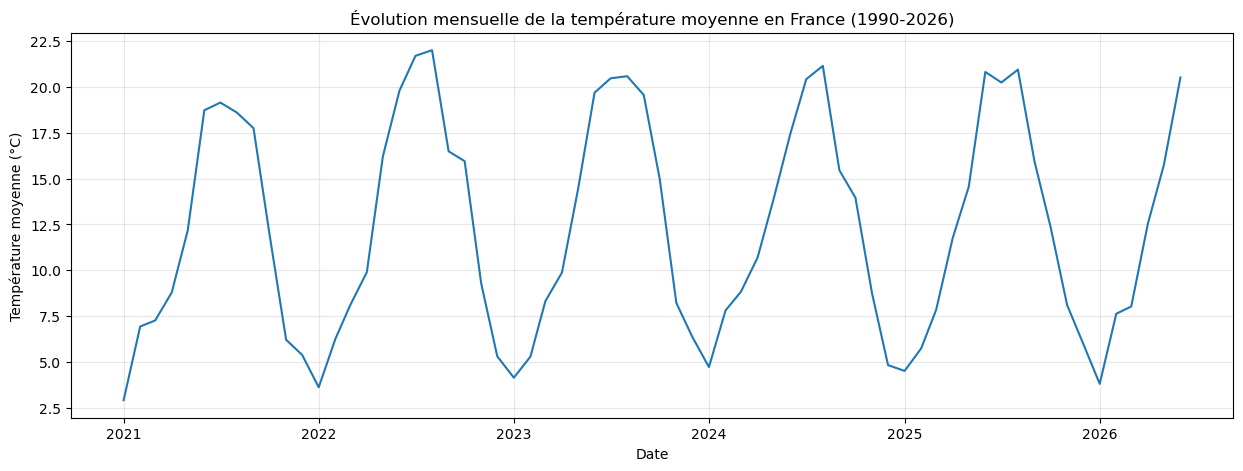

In [98]:
#-------------------
# Évolution mensuelle de la température moyenne en France
#-------------------

# Température moyenne nationale par mois
temp_france = (
    df.groupby("MOIS_ANNEE")["TEMP_MOYENNE_C"]
      .mean()
      .sort_index()
)

# Conversion de Period[M] -> Timestamp pour l'affichage
temp_france.index = temp_france.index.to_timestamp()

plt.figure(figsize=(15, 5))
plt.plot(temp_france.index, temp_france.values)

plt.title("Évolution mensuelle de la température moyenne en France (1990-2026)")
plt.xlabel("Date")
plt.ylabel("Température moyenne (°C)")
plt.grid(alpha=0.3)

plt.show()

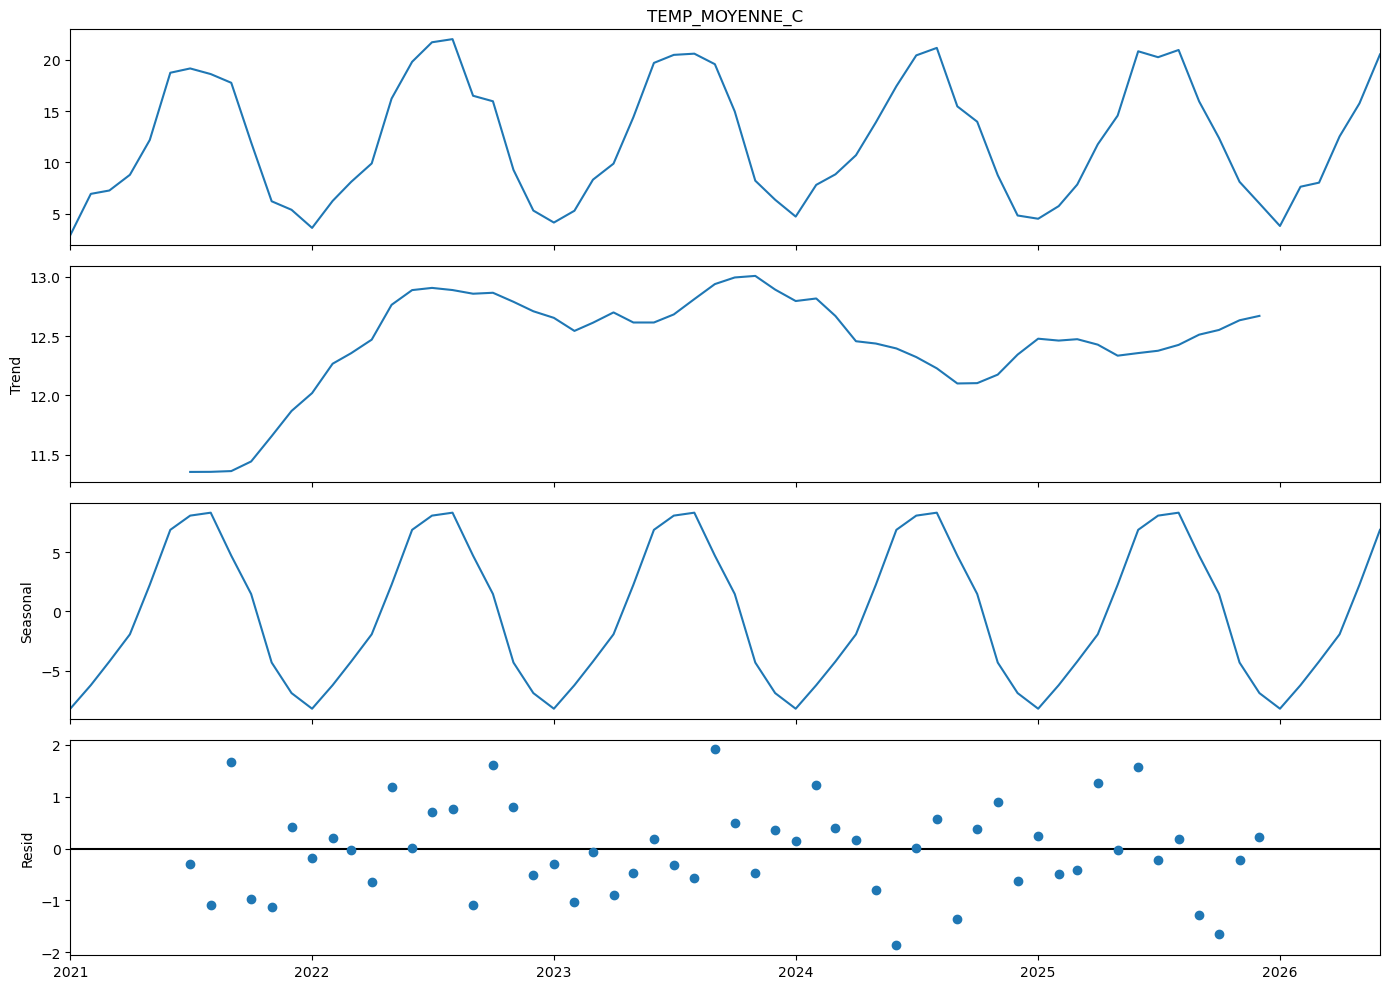

In [99]:
#-------------------
# Analyse de la série temporelle
#-------------------


from statsmodels.tsa.seasonal import seasonal_decompose

# Série mensuelle
ts = (
    df.groupby("MOIS_ANNEE")["TEMP_MOYENNE_C"]
      .mean()
      .sort_index()
)

# Passage en Timestamp
ts.index = ts.index.to_timestamp()

# Décomposition additive (période = 12 mois)
decomposition = seasonal_decompose(
    ts,
    model="additive",
    period=12
)

fig = decomposition.plot()
fig.set_size_inches(14, 10)

plt.tight_layout()
plt.show()

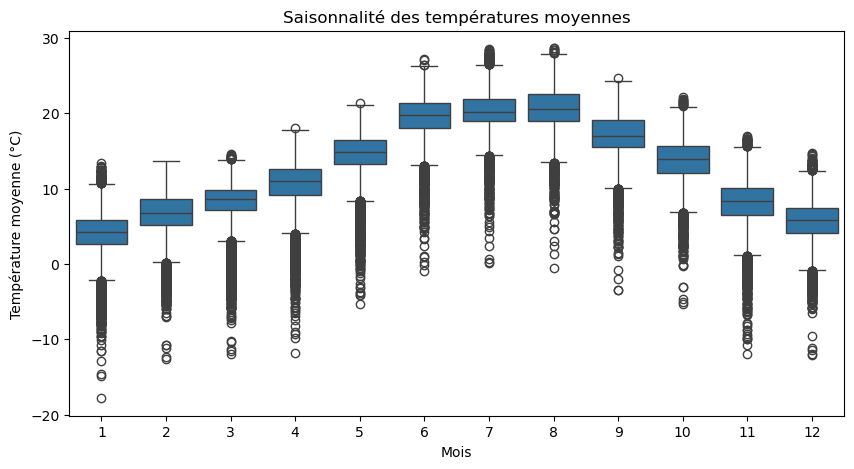

In [100]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x=df["MOIS_ANNEE"].dt.month,
    y="TEMP_MOYENNE_C"
)

plt.xlabel("Mois")
plt.ylabel("Température moyenne (°C)")
plt.title("Saisonnalité des températures moyennes")

plt.show()

<Figure size 1000x400 with 0 Axes>

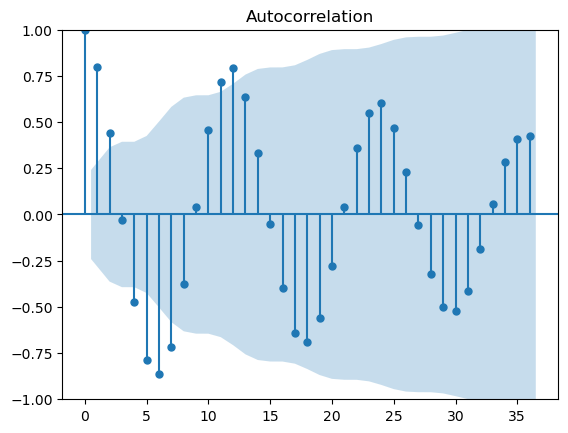

In [101]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,4))
plot_acf(ts, lags=36)

plt.show()

### Analyse de la série temporelle des températures moyennes

L'évolution mensuelle de la température moyenne met en évidence une **forte saisonnalité annuelle**, avec des températures minimales observées en hiver (janvier-février) et maximales en été (juillet-août). Ce cycle se répète de manière régulière sur l'ensemble de la période étudiée.

La décomposition de la série temporelle confirme cette observation :
- la **composante saisonnière** présente un cycle annuel très marqué et stable d'une année à l'autre ;
- la **tendance** montre de légères fluctuations mais reste globalement stable sur la période observée. La durée de la série (2021-2026) reste toutefois limitée pour mettre en évidence une évolution climatique de long terme ;
- les **résidus** sont globalement centrés autour de zéro et ne présentent pas de structure particulière, ce qui indique que la majeure partie de la variabilité est expliquée par la tendance et surtout par la saisonnalité.

Le boxplot par mois confirme cette saisonnalité : les températures augmentent progressivement du début de l'année jusqu'au cœur de l'été, avant de diminuer à l'automne et en hiver. La dispersion des températures est également plus importante durant les mois estivaux.

Enfin, la fonction d'autocorrélation (ACF) met en évidence une forte corrélation pour un décalage de **12 mois**, ainsi que pour ses multiples (24, 36 mois), ce qui confirme l'existence d'une **saisonnalité annuelle** caractéristique des données climatiques.